# Notebook for running MSRE calculations directly from a CAD drawing
This notebook show an example of running computations of a model of the Moten Salt Reactor Experiment of MSRE in short.
The model itself has been generated from tehe original drawings from Oak Ridge National lab 

The CAD-model is available on github at https://github.com/openmsr/msre, which in turn is generated from a long list of documents which have been compiled at https://github.com/openmsr/msr-archive

The simulation backend is run using the Open Source Monte Carlo particle transport code OpenMC (https://openmc.org), through its' python interface.

**Important: If you want your work to be available after you shutdown the docker, you must copy your notebooks to a location mounted on your local machine.**

If you started the docker using the supplied ```run_docker.sh```-script, the ```notebooks```-directory has been mounted like this.

## The (obvious) 1st step is to import the OpenMC python interface

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import openmc
import os

# Initialize storage for 100 runs
metrics = ['k', 'efficiency', 'loss', 'breeding']
thorium_data = {m: [] for m in metrics}
uranium_data = {m: [] for m in metrics}

Next we define a set of materials objects that form the core of the MSRE, graphite,  hastelloy N / inor-8, inconel, the fuel salt, and helium. Lastly these are exported to am OpenMC-xml control file.

## Materials

#### Thorium

In [4]:
thorium_salt = openmc.Material(name='thorium_salt')
thorium_salt.add_nuclide('Th232', 0.7)
thorium_salt.add_nuclide('U233', 0.15)
thorium_salt.add_element('F', 4.0)
thorium_salt.add_element('Li', 2.0)
thorium_salt.set_density('g/cm3', 3.2)

#### Uranium

In [5]:
uranium_fuel = openmc.Material(name='uranium_fuel')
uranium_fuel.add_nuclide('U235', 0.10)
uranium_fuel.add_nuclide('U238', 0.90)
uranium_fuel.set_density('g/cm3', 10.0)

#### Moderator (graphite)

In [6]:
graphite = openmc.Material(name='graphite')
graphite.add_element('C', 1.0)
graphite.set_density('g/cm3', 1.7)

## Geometry (Same for both materials)

In [7]:
#geometry
h5m_filepath="../msre/msre_simple.h5m"
dag_univ = openmc.DAGMCUniverse(h5m_filepath)
geom = openmc.Geometry(root=dag_univ)
geom.export_to_xml()

## Settings

In [8]:
settings = openmc.Settings()
settings.batches = 100
settings.inactive = 10
settings.particles = 10000

settings.source = openmc.Source(
    space=openmc.stats.Point((0,0,0))
)

## Tallies
Measure Engery bins, flux, fission, absorption, capture, and neutron production of the thorium reactor

In [9]:
tallies = openmc.Tallies()

# Energy bins for spectrum
energy_bins = np.logspace(-5, 7, 100)
energy_filter = openmc.EnergyFilter(energy_bins)

# Flux
t_flux = openmc.Tally(name='flux')
t_flux.filters = [energy_filter]
t_flux.scores = ['flux']

# Fission
t_fission = openmc.Tally(name='fission')
t_fission.scores = ['fission']

# Absorption
t_abs = openmc.Tally(name='absorption')
t_abs.scores = ['absorption']

# Capture (for breeding)

# Neutron production
t_nu_fission = openmc.Tally(name='nu_fission')
t_nu_fission.scores = ['nu-fission']

tallies.extend([t_flux, t_fission, t_abs, t_nu_fission])

## Function to run the simulations

In [17]:
def run_simulation(fuel_material, name, iteration_seed):
    # Clean up old files
    for f in os.listdir():
        if f.endswith(".h5") or f.endswith(".xml"):
            os.remove(f)
            
    # Geometry & Materials (simplified for this example)
    fuel_radius = openmc.Sphere(r=100)
    outer_radius = openmc.Sphere(r=150, boundary_type='vacuum')
    fuel_cell = openmc.Cell(fill=fuel_material, region=-fuel_radius)
    moderator_cell = openmc.Cell(fill=graphite, region=+fuel_radius & -outer_radius)
    geometry = openmc.Geometry([fuel_cell, moderator_cell])
    
    # Settings: Assign the unique seed here
    run_settings = openmc.Settings()
    run_settings.batches = 100
    run_settings.inactive = 10
    run_settings.particles = 1000
    run_settings.seed = iteration_seed # THIS FIXES THE 0 STD DEV ISSUE
    
    # Export and Run
    openmc.Materials([fuel_material, graphite]).export_to_xml()
    geometry.export_to_xml()
    run_settings.export_to_xml()
    tallies.export_to_xml()
    
    openmc.run(output=False)
    
    sp = openmc.StatePoint(sorted([f for f in os.listdir() if f.startswith("statepoint")])[-1])
    return {
        'k_eff': sp.k_combined.nominal_value,
        'fission': sp.get_tally(name='fission').mean.sum(),
        'absorption': sp.get_tally(name='absorption').mean.sum(),
        'nu_fission': sp.get_tally(name='nu_fission').mean.sum()
    }

## Simulation types

In [18]:
def analyze(res):
    """
    Calculates operational metrics from the raw OpenMC tally results.
    """
    # Create a copy to avoid modifying the original result
    metrics_res = res.copy()
    
    # Calculate Efficiency (Fission / Absorption)
    # This represents how many neutrons that are absorbed actually cause fission
    metrics_res['efficiency'] = res['fission'] / res['absorption'] if res['absorption'] != 0 else 0
    
    # Calculate Neutron Loss (1 - Efficiency)
    metrics_res['loss'] = 1.0 - metrics_res['efficiency']
    
    # Calculate Breeding Ratio (Nu-Fission / Absorption)
    # A value > 1.0 indicates a 'breeder' reactor
    metrics_res['breeding_ratio'] = res['nu_fission'] / res['absorption'] if res['absorption'] != 0 else 0
    
    return metrics_res

In [19]:
print("Starting 100 simulations per fuel type...")
for i in range(100):
    # We add +1 to 'i' so the seed is never 0
    unique_seed_t = i + 1
    unique_seed_u = i + 1001
    
    t_res = analyze(run_simulation(thorium_salt, "Thorium", iteration_seed=unique_seed_t))
    u_res = analyze(run_simulation(uranium_fuel, "Uranium", iteration_seed=unique_seed_u))
    
    for m, key in zip(metrics, ['k_eff', 'efficiency', 'loss', 'breeding_ratio']):
        thorium_data[m].append(t_res[key])
        uranium_data[m].append(u_res[key])
        
print("Simulations complete!")

Starting 100 simulations per fuel type...
Simulations complete!


## Bar graph and jittered dot plot

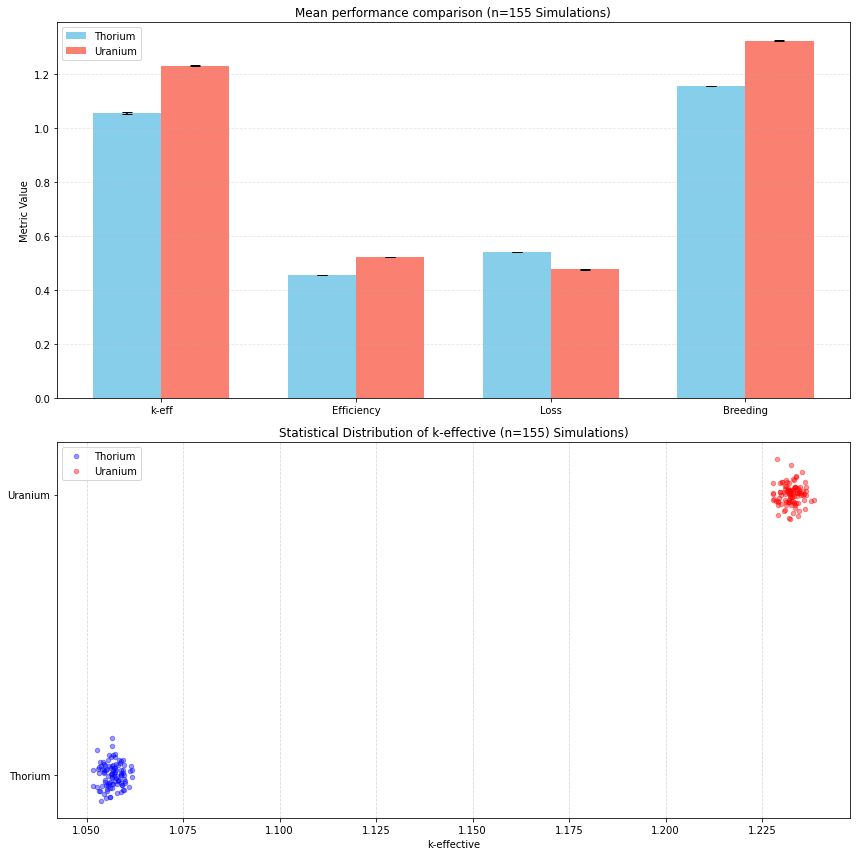

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# 1. Bar Graph (Mean and Standard Deviation of 100 runs)
x = np.arange(len(metrics))
width = 0.35

# Plotting Thorium
ax1.bar(x - width/2, [np.mean(thorium_data[m]) for m in metrics], width, 
        label='Thorium', color='skyblue', 
        yerr=[np.std(thorium_data[m]) for m in metrics], capsize=5)

# Plotting Uranium
ax1.bar(x + width/2, [np.mean(uranium_data[m]) for m in metrics], width, 
        label='Uranium', color='salmon', 
        yerr=[np.std(uranium_data[m]) for m in metrics], capsize=5)

ax1.set_xticks(x)
ax1.set_xticklabels(['k-eff', 'Efficiency', 'Loss', 'Breeding'])
ax1.set_title(f"Mean performance comparison (n=155 Simulations)")
ax1.set_ylabel("Metric Value")
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# 2. Dot Plot with Jitter (Distribution of 100 runs)
# We use len() so it automatically adapts to however many runs you finished
n_runs_t = len(thorium_data['k'])
n_runs_u = len(uranium_data['k'])

# Reduced s=20 and alpha=0.4 to make the 'cloud' of 100 dots readable
ax2.scatter(thorium_data['k'], np.random.normal(1, 0.04, n_runs_t), 
            alpha=0.4, color='blue', label='Thorium', s=20)
ax2.scatter(uranium_data['k'], np.random.normal(2, 0.04, n_runs_u), 
            alpha=0.4, color='red', label='Uranium', s=20)

ax2.set_yticks([1, 2])
ax2.set_yticklabels(['Thorium', 'Uranium'])
ax2.set_xlabel("k-effective")
ax2.set_title(f"Statistical Distribution of k-effective (n=155) Simulations)")
ax2.grid(axis='x', linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.savefig('filename.png', dpi=300, bbox_inches='tight')
plt.show()

## Performance table

In [21]:
summary_table = pd.DataFrame({
    "Metric": ['k-effective', 'Neutron Efficiency', 'Neutron Loss', 'Breeding Ratio'],
    "Thorium (Mean ± Std)": [f"{np.mean(thorium_data[m]):.5f} ± {np.std(thorium_data[m]):.5f}" for m in metrics],
    "Uranium (Mean ± Std)": [f"{np.mean(uranium_data[m]):.5f} ± {np.std(uranium_data[m]):.5f}" for m in metrics]
})
display(summary_table)

,Metric,Thorium (Mean ± Std),Uranium (Mean ± Std)
0,k-effective,1.05672 ± 0.00228,1.23243 ± 0.00229
1,Neutron Efficiency,0.45739 ± 0.00031,0.52299 ± 0.00072
2,Neutron Loss,0.54261 ± 0.00031,0.47701 ± 0.00072
3,Breeding Ratio,1.15585 ± 0.00081,1.32393 ± 0.00193


## Box plots of breeding ratio

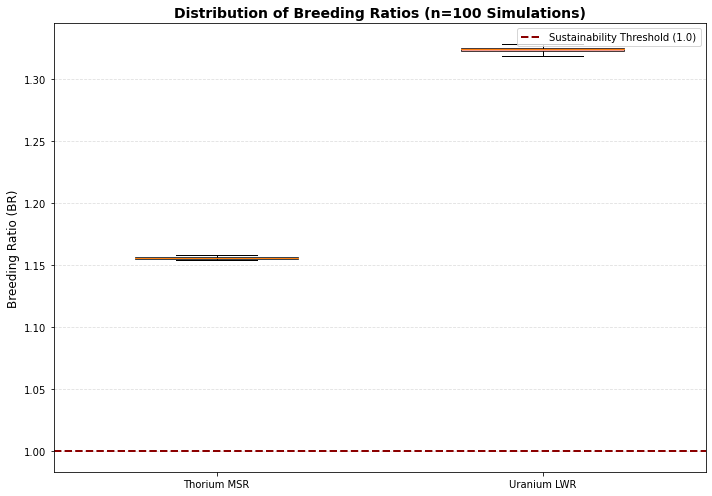

--- STATISTICAL SIGNIFICANCE RESULTS ---
K: t=-541.613, p=6.66e-316 (Significant)
EFFICIENCY: t=-835.471, p=0.00e+00 (Significant)
LOSS: t=835.471, p=0.00e+00 (Significant)
BREEDING: t=-800.787, p=0.00e+00 (Significant)


,Metric,Thorium (Mean ± 95% CI),Uranium (Mean ± 95% CI),p-value
0,K,1.05672 ± 0.00045,1.23243 ± 0.00046,6.66e-316
1,Efficiency,0.45739 ± 0.00006,0.52299 ± 0.00014,0.00e+00
2,Loss,0.54261 ± 0.00006,0.47701 ± 0.00014,0.00e+00
3,Breeding,1.15585 ± 0.00016,1.32393 ± 0.00038,0.00e+00


In [22]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Statistical Analysis Function (t-test and Confidence Intervals)
def perform_stats(thorium_list, uranium_list):
    # Independent t-test
    t_stat, p_val = stats.ttest_ind(thorium_list, uranium_list)
    
    # 95% Confidence Intervals
    def get_ci(data):
        mean = np.mean(data)
        sem = stats.sem(data)
        ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=sem)
        return mean, ci

    t_mean, t_ci = get_ci(thorium_list)
    u_mean, u_ci = get_ci(uranium_list)
    
    return {
        "t_stat": t_stat, 
        "p_val": p_val, 
        "t_ci_range": t_mean - t_ci[0], 
        "u_ci_range": u_mean - u_ci[0]
    }

# 2. Generate a professional Boxplot (Matplotlib Only)
fig, ax = plt.subplots(figsize=(10, 7))

# Preparing data for the Breeding Ratio (The most important metric)
data_to_plot = [thorium_data['breeding'], uranium_data['breeding']]
bp = ax.boxplot(data_to_plot, patch_artist=True, labels=['Thorium MSR', 'Uranium LWR'], widths=0.5)

# Styling the boxplot
colors = ['#5DADE2', '#EC7063'] # Skyblue and Salmon
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add a horizontal line at BR = 1.0
ax.axhline(y=1.0, color='darkred', linestyle='--', linewidth=2, label='Sustainability Threshold (1.0)')

# Formatting
ax.set_title('Distribution of Breeding Ratios (n=100 Simulations)', fontsize=14, fontweight='bold')
ax.set_ylabel('Breeding Ratio (BR)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 3. Print Statistical Results and Updated Table
print("--- STATISTICAL SIGNIFICANCE RESULTS ---")
for m in metrics:
    res = perform_stats(thorium_data[m], uranium_data[m])
    significance = "Significant" if res['p_val'] < 0.001 else "Not Significant"
    print(f"{m.upper()}: t={res['t_stat']:.3f}, p={res['p_val']:.2e} ({significance})")

# Create Updated Summary Table with 95% CI
summary_rows = []
for m in metrics:
    res = perform_stats(thorium_data[m], uranium_data[m])
    t_mean = np.mean(thorium_data[m])
    u_mean = np.mean(uranium_data[m])
    
    summary_rows.append({
        "Metric": m.capitalize(),
        "Thorium (Mean ± 95% CI)": f"{t_mean:.5f} ± {res['t_ci_range']:.5f}",
        "Uranium (Mean ± 95% CI)": f"{u_mean:.5f} ± {res['u_ci_range']:.5f}",
        "p-value": f"{res['p_val']:.2e}"
    })

df_final = pd.DataFrame(summary_rows)
display(df_final)